In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reading the AmesHousing database


---


ابتدا باید فایل دیتابیس که از سایت کگل دانلود کرده ایم را به کمک کتابخانه پانداس بخوانیم و این دیتابیس را در یک متغیر ذخیره کنیم.

In [ ]:
df = pd.read_csv('/content/sample_data/AmesHousing.csv')

print("Dataset dimensions :")
print(f"Rows = {df.shape[0]} and Columns = {df.shape[1]}")
print('\n\n\n')
print(df)

# Preliminary Review


---


میخواهیم یک بررسی اولیه انجام دهیم تا ساختار کلی دیتابیس را متوجه شوبم.

برای اینکار اول از دستور head استفاده کردیم که ۵ سطر ابتدایی را به ما نشان میدهد البته میتوان داخل پرانتز ان تعداد سطری که میخواهیم به نمایش دربیاید را نیز بنویسیم.

دستور بعدی info است که اطلاعاتی مثل دیتاتایپ ستون ها را به ما میدهد.

همچنین دستور describe اطلاعاتی راجع به مقدار های ستون ها به ما میدهد مثلا تعداد و میانگین و انحراف معیار و کمترین و بیشترین داده ها در هر ستون.

همچنین برای اینکه بفهمیم چند داده گمشده داریم باید به دستور info نکاه کنیم که در ستون Non-Null Count تعداد داده های پر شده نوشته شده است.

In [58]:
print("---The first five rows of the dataset---\n".center(120))
display(df.head())

print('\n\n\n')
print("---Column information and data types---\n")
df.info()

print('\n\n\n')
print("---Descriptive statistics of the variables---".center(120))
display(df.describe())

missing_counts = df.isnull().sum()
print('\n\n\n')
print("---count of missing data in each column---\n".center(120))
print(missing_counts)

                                       ---The first five rows of the dataset---
                                        


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900






---Column information and data types---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type      

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000






                                         count of missing data in each column
                                          
Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64


# Histogram
دراینجا نمودار هیستوگرام برای داده های اولیه را رسم کردم سپس مدل لوگاریتمی ان را رسم کردم که داده ها بیشتر در وسط متمرکز بودند به خاطر همین چولگی نمودار کمتر بود و در نتیحه تقریبا نمودار نرمال بود.
> **همچنین تابع چگالی احتمال توزیع نرمال از رابطه زیر بدست میاید :**





# ***$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2}$$***

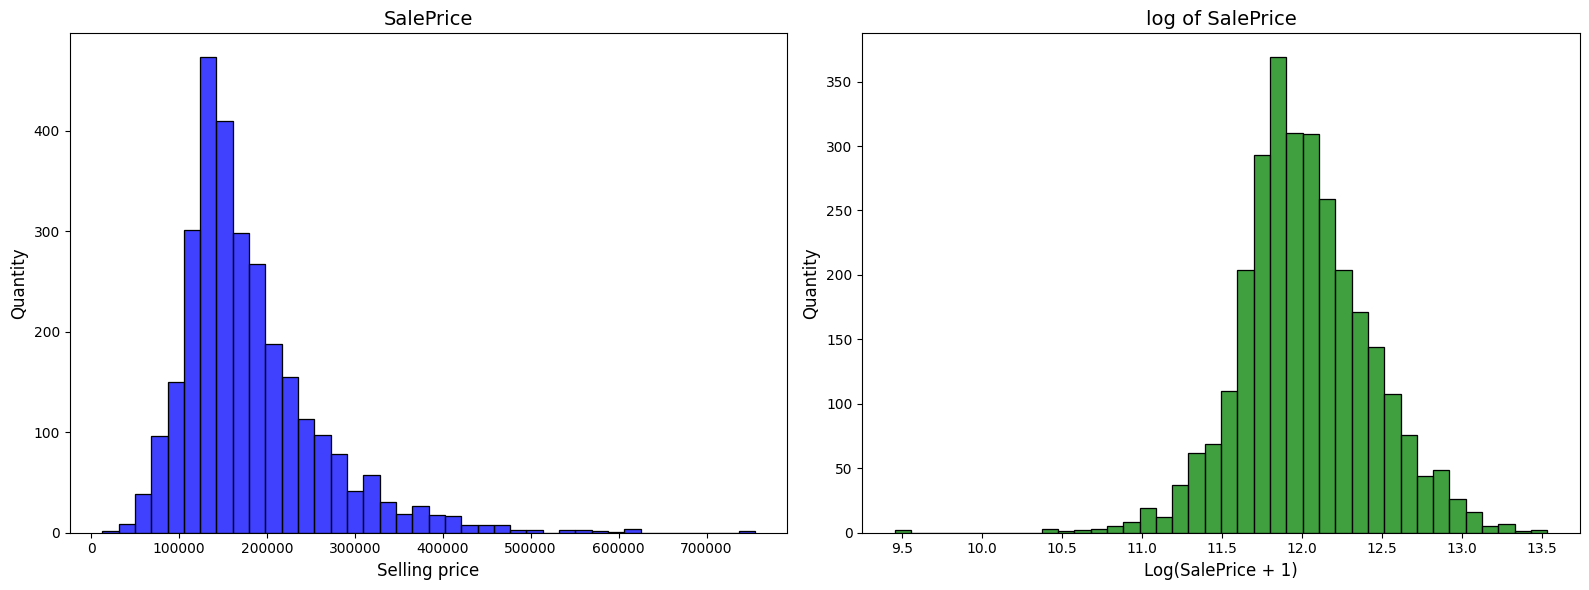

Skewness of the initial histogram : 1.74
Skewness of the logarithmic histogram : -0.01
The initial histogram is unnormal.
The logarithmic histogram is normal.


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['SalePrice'], color='blue', ax=axes[0], bins=40)
axes[0].set_title('SalePrice', fontsize=14)
axes[0].set_xlabel('Selling price', fontsize=12)
axes[0].set_ylabel('Quantity', fontsize=12)

sns.histplot(np.log1p(df['SalePrice']), color='green', ax=axes[1], bins=40)
axes[1].set_title('log of SalePrice', fontsize=14)
axes[1].set_xlabel('Log(SalePrice + 1)', fontsize=12)
axes[1].set_ylabel('Quantity', fontsize=12)

plt.tight_layout()
plt.show()
initial_skewness = df['SalePrice'].skew()
log_skewness = np.log1p(df['SalePrice']).skew()
print(f"Skewness of the initial histogram : {initial_skewness:.2f}")
print(f"Skewness of the logarithmic histogram : {log_skewness:.2f}")
if (initial_skewness < 0.5 and initial_skewness > -0.5) :
  print("The initial histogram is normal.")
else :
  print("The initial histogram is unnormal.")
if (log_skewness < 0.5 and log_skewness > -0.5) :
  print("The logarithmic histogram is normal.")
else :
  print("The logarithmic histogram is unnormal.")

# Missing data management


In [47]:
numerical = df.select_dtypes(include=[np.number]).columns.tolist()
categorical = df.select_dtypes(include=['object', 'category']).columns.tolist()

for i in numerical:
    if df[i].isnull().sum() == df.shape[0]:
        df[i].fillna(0, inplace=True)
    elif df[i].isnull().sum() > 0:
        mean = df[i].median()
        df[i].fillna(mean, inplace=True)

for i in categorical:
    if df[i].isnull().sum() == df.shape[0]:
        df[i].fillna("None", inplace=True)
    elif df[i].isnull().sum() > 0:
        mod = df[i].mode()[0]
        df[i].fillna(mod, inplace=True)
print(df)

      Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0         1  526301100           20        RL         141.0     31770   Pave   
1         2  526350040           20        RH          80.0     11622   Pave   
2         3  526351010           20        RL          81.0     14267   Pave   
3         4  526353030           20        RL          93.0     11160   Pave   
4         5  527105010           60        RL          74.0     13830   Pave   
...     ...        ...          ...       ...           ...       ...    ...   
2925   2926  923275080           80        RL          37.0      7937   Pave   
2926   2927  923276100           20        RL          68.0      8885   Pave   
2927   2928  923400125           85        RL          62.0     10441   Pave   
2928   2929  924100070           20        RL          77.0     10010   Pave   
2929   2930  924151050           60        RL          74.0      9627   Pave   

     Alley Lot Shape Land Contour  ... 

# Categorical Data Encoding

In [65]:
encoded_cols = pd.get_dummies(df[['Neighborhood', 'House Style']], drop_first=True, dtype=int)
print(f"Number of new features generated by one-hot encoding : {encoded_cols.shape[1]}")
print('\n\n\n')
encoded_cols.head()

Number of new features generated by one-hot encoding : 34






,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,...,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,House Style_1.5Unf,House Style_1Story,House Style_2.5Fin,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,House Style_SLvl
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
